In [85]:
from sklearn.linear_model import LogisticRegression
import pandas as pd 
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

- If the labels are three it internally uses soft_max
- sag and saga we use this when we have more features in sentance based classification

In [86]:
df=pd.read_csv('loan_approval_dataset.csv')


In [87]:
X=df.drop(columns='Loan_Approved')
Y=df.Loan_Approved

In [88]:
df.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [89]:
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,train_size=0.8,random_state=42)

In [90]:
num_cols=X.select_dtypes(include='number').columns
obj_cols=X.select_dtypes(include='object').columns

<Axes: >

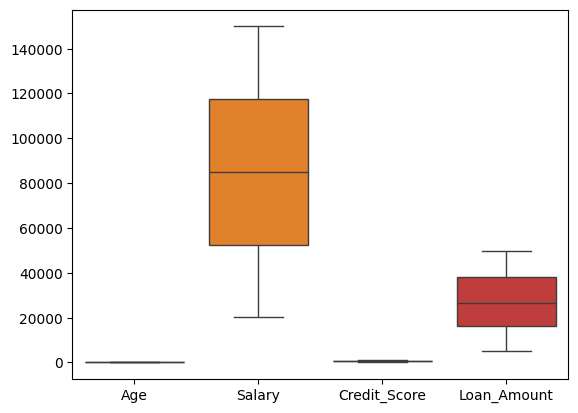

In [91]:
sns.boxplot(df[num_cols])

Why scaling?
- Feature (numerical)cols values are in different range(scale). So we can use Scaling to give equal importance for all  feature cols.

Why encoding?
- Algorithms can understand only numbers not strings

Which scaling technique?
- As we can see in the above box plot there are not outliers present hence we can use normalization technique, i.e MinMaxScaler( )

Which encoding technique?
- Loan_Term            4
- Employment_Status    3
- Residence_Type       3
- Previous_Default     2
- As we have more than one feature column and less unique values so we can use OneHotEnocoder()

In [92]:
X[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

In [93]:
preprocessing=ColumnTransformer(
    transformers=[
        ('scaler',MinMaxScaler(),num_cols),
        ('encode', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), obj_cols)
    ],
    remainder='passthrough'
)

In [94]:
main_pipeline=Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', LogisticRegression())
    ]
)

In [95]:
grid_search_cv=GridSearchCV(
    estimator=main_pipeline,
    param_grid={
        'model__penalty':['l2', 'l1'],
        'model__solver':[ 'liblinear', 'saga'],
        'model__max_iter': [100]

    },
    verbose=1
)
grid_search_cv.fit(xtrain,ytrain)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'model__max_iter': [100], 'model__penalty': ['l2', 'l1'], 'model__solver': ['liblinear', 'saga']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scaler', ...), ('encode', ...)]"


In [96]:
grid_search_cv.best_estimator_

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('encode', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [97]:
grid_search_cv.best_params_

{'model__max_iter': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

In [98]:
# scale=MinMaxScaler()
# updated_Xtrain=scale.fit_transform(xtrain[num_cols])
# updated_Ytrain=scale.transform(xtest[num_cols])

In [99]:
# encode=OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# values=encode.fit_transform(xtrain[obj_cols])
# cols=encode.get_feature_names_out()

In [100]:
# xtrain[cols]=values

In [101]:
# xtrain.drop(columns=['Loan_Term','Employment_Status','Residence_Type','Previous_Default'],inplace=True)

In [102]:
# xtrain

In [103]:
# val=encode.transform(xtest[obj_cols])
# col=encode.get_feature_names_out()

In [104]:
# xtest[col]=val

In [105]:
# xtest.drop(columns=['Loan_Term','Employment_Status','Residence_Type','Previous_Default'],inplace=True)
# xtest

In [106]:
# model=LogisticRegression(max_iter=1000, penalty=None)
# # model.fit(xtrain,ytrain)

In [107]:
# model.n_iter_

In [108]:
# ypred_train=model.predict(xtrain)
# ypred_test=model.predict(xtest)

In [109]:
# df["Loan_Approved"].value_counts()

- The Data set is balanced

## train data unique value counts

In [110]:
# ytrain.value_counts()

## test data unique value counts

In [111]:
# ytest.value_counts()

## 1) Confusion matrix

In [112]:
# train_matrix=confusion_matrix(ytrain,ypred_train)

In [113]:
# np.sum(train_matrix[:,1])
# np.sum(train_matrix[:,0])

- Out of 397 actual "No" samples, 204 were correctly classified as "No" (True Negatives), while 193 were incorrectly classified as "Yes" (False Positives).
- Out of 403 actual "Yes" samples, 232 were correctly classified as "Yes" (True Positives), while 171 were incorrectly classified as "No" (False Negatives).

In [114]:
# confusion_matrix(ytest,ypred_test)

- Out of 95 actual "No" samples, 47 were correctly classified as "No" (True Negatives), while 48 were incorrectly classified as "Yes" (False Positives).
- Out of 105 actual "Yes" samples, 53  were correctly classified as "Yes" (True Positives), while 52  were incorrectly classified as "No" (False Negatives).

## 2) Precision Score

***For train data***

In [115]:
# print(precision_score(ytrain,ypred_train,pos_label='No'))
# print(precision_score(ytrain,ypred_train,pos_label='Yes'))

- Out of all predicted "No" labels (375),54% samples are correctly predicted as "No" (True Negatives), while 46% samples were wrongly predicted as "Yes" (False Negatives).
- Out of all predicted "Yes" labels (425), 54% samples are correctly predicted as "Yes"(True Positive) , while 46% samples were wrongly predicted as "No" (False Positive)

***For test data***

In [116]:
# print(precision_score(ytest,ypred_test,pos_label='No'))
# print(precision_score(ytest,ypred_test,pos_label='Yes'))

- Out of all predicted "No" (99),47% samples are correctly predicted as "No" (True Negatives), while 53% samples were wrongly predicted as "Yes" (False Negatives).
- Out of all predicted "Yes" labels (101), 52% samples are correctly predicted as "Yes"(True Positive) , while 48% samples were wrongly predicted as "No" (False Positive)

## 3) Recall Score

***For train data***

In [117]:
# print(recall_score(ytrain,ypred_train,pos_label='No'))
# print(recall_score(ytrain,ypred_train,pos_label='Yes'))

- Out of all actual 'No' labels (397), 51% of samples are correctly predicted as 'No' (True Negative), while 49% samples are wrongly predicted as 'Yes' (False Negative)
- Out of all actual 'Yes' labels (403), 57% of samples are correclty predicted as 'Yes' (True Positive), while 43% of samples are wrongly predicted as 'No' (False Negative)

***For test data***

In [118]:
# print(recall_score(ytest,ypred_test,pos_label='No'))
# print(recall_score(ytest,ypred_test,pos_label='Yes'))

- Out of all actual 'No' lables (95), 49% of samples are correclty predicted as 'No'(True Negative) while 51% of samples are wrongly predicted as 'Yes'(False Negative).
- Out of all actual 'Yes' labels (105), 50% of samples are correclty predicted as 'Yes'(True Negative), while 50% of samples are wrongly predicted as 'No'(False Negative)

## 4) Accuracy Score

- To check the accuracy score we need to first check the data is balanced or imbalanced , because we can use this accuracy_score for only balanced datasets

In [119]:
# ytrain.value_counts()

- As we can see the above target columns labels values has less difference, so the data set is balanced we can use the accuracy score 

In [120]:
# accuracy_score(ytrain,ypred_train)

- Out of all 800 samples, 54% samples are correclty predcited  and 46% samples are wrongly predicted.

In [121]:
# accuracy_score(ytest, ypred_test)

- Out of all 200 samples, 50% samples are correclty predicted and 50% samples are wrongly predicted.

## 5) f1 Score

- We use this metric when we have imbalanced data set

In [122]:
# print(f1_score(ytrain,ypred_train, pos_label='No'))
# print(f1_score(ytrain,ypred_train, pos_label='Yes'))

In [123]:
# print(f1_score(ytest,ypred_test, pos_label='No'))
# print(f1_score(ytest,ypred_test, pos_label='Yes'))

***Conclusion***

- Model performance on train data is bad, so model is not learned train data patterns properly.
- Also model performance on test data is bad, so model is not learned test data patterns properly.
- So here the model is underfit, model is too simple not able to capture the complex patterns

In [124]:
# from sklearn.metrics import classification_report
# print('Classification_report\n',classification_report(ytrain,ypred_train))

- Macro it takes the average of metrics & tells overall conclusion of yes and no labels, out of all predicted lables how many predicted correclty, it takes the average of all class labels.
- Weighted uses a metric and support 

In [125]:
# print('Classification_report\n',classification_report(ytest,ypred_test))